# order_cells: the memory of the walk, and three more orderings

A note on `FlwdirRaster.order_cells`. It puts the cells in an order where a cell
comes after the cell it drains into, and every kernel that accumulates upstream
reads that order backwards. Two ways to build one are in the library, `"sort"`
and `"walk"`. This notebook writes out five, measures what each costs to build
and what it then costs `streams.accuflux`, the upstream drainage area, and
proposes one change and two additions.

**The change.** `"walk"` spends its memory on `core.upstream_matrix`, a dense
array several times larger than the information in it. The same upstream cells in
compressed sparse row layout give back the same sequence element by element, for
a fraction of the memory and less time. Nothing else about the method changes.
That is what I have opened as a pull request, and section 1 is the whole of it.

**The additions.** Two more traversals are cheaper to build than anything in the
library today. Whether they are worth having is less clear cut, because which one
`accuflux` prefers **depends on the size of the raster**: on the Rhine example
depth-first is the slowest of the five, and on a raster two thousand times larger
it is the fastest, same machine, same code. Section 4 works out why and section 5
shows the turn.

Throughout, `n` is the number of cells in the raster, `e` the number of them that
drain into another cell, and `d` the largest number of cells draining into any
one cell. On a D8 raster `d` is at most 8, and 7 on the example below, while the
average number of cells draining into a cell is close to 1; `e < n` because a
cell drains to at most one other.

Sections 1 to 4 run against pyflwdir as released, on this repository's
`examples/rhine_d8.tif`; run the notebook from the `examples` folder so the file
resolves. The five orderings are written out rather than imported, so nothing
needs patching. Section 5 uses a raster that is not in the repository; its numbers come
from `examples/bench_large.py`, which reproduces them from any raster that size.

All timings are from one machine, an Apple M1 Max: 8 performance cores, 128 KB of
level 1 data cache each, 12 MB of level 2 shared between them, 64 GiB of memory.
That is a large level 2 cache, and section 4 shows it is what decides the second
finding. An Intel Xeon Platinum 8270, for comparison, has 32 KB of level 1 and
1 MB of level 2 per core.

*Prepared with Claude Code.*

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from numba import njit

import pyflwdir
from pyflwdir import core, streams

with rasterio.open("rhine_d8.tif", "r") as src:
    flwdir, transform = src.read(1), src.transform

flw = pyflwdir.from_array(flwdir, ftype="d8", transform=transform, latlon=True)
idxs_ds, idxs_pit, mv = flw.idxs_ds, flw.idxs_pit, flw._mv
n, ncol, itemsize = idxs_ds.size, flw.shape[1], idxs_ds.itemsize
n_valid = int(np.sum(idxs_ds != mv))
n_links = int(np.sum((idxs_ds != mv) & (idxs_ds != np.arange(n, dtype=idxs_ds.dtype))))
d = int(core.upstream_count(idxs_ds, mv=mv).max())

print(f"{flw.shape[0]} x {flw.shape[1]} = {n:,} cells, {n_valid:,} in the basin,")
print(f"{n_links:,} of which drain into another cell, {idxs_pit.size} pit.")
print(f"At most {d} cells drain into one cell. Index dtype {idxs_ds.dtype}.")

682 x 997 = 679,954 cells, 349,847 in the basin,
349,846 of which drain into another cell, 1 pit.
At most 7 cells drain into one cell. Index dtype int32.


## 1. The memory of the walk path

`core.idxs_seq` builds `core.upstream_matrix` first: `n` rows of `d` entries.
Rows are allocated for nodata cells too and every row is padded out to `d`, so of
the `n * d` entries only `e` carry a cell.

The same information fits in compressed sparse row layout: `n + 1` offsets plus
one entry per upstream cell, `n + 1 + e` in all.

In [2]:
dense = n * d * itemsize
csr = (n + 1 + n_links) * itemsize
print(f"upstream_matrix   {n:,} x {d} x {itemsize} B = {dense / 1e6:8.1f} MB")
print(f"upstream_csr      ({n:,} + 1 + {n_links:,}) x {itemsize} B = {csr / 1e6:8.1f} MB")
print(f"                  {dense / csr:.1f} times smaller, and "
      f"{100 * (1 - n_valid / n):.0f}% of this raster is not even in the basin")

upstream_matrix   679,954 x 7 x 4 B =     19.0 MB
upstream_csr      (679,954 + 1 + 349,846) x 4 B =      4.1 MB
                  4.6 times smaller, and 49% of this raster is not even in the basin


19 MB is nothing to worry about; section 5 runs the same arithmetic on a raster
where it is 39.7 GiB.

## 2. Five orderings

Two things vary independently: which traversal produces the order, and how the
upstream cells are stored while it runs. The first sets what the kernel sees, the
second sets what the ordering costs to build.

| | in pyflwdir | traversal | upstream cells held as |
|---|---|---|---|
| `sort` | yes, `method="sort"` | breadth-first, reached by sorting `core.rank` | nothing, the ranks are enough |
| `walk` | yes, `method="walk"` | breadth-first from the pits | dense `(n, d)` matrix |
| `walk + CSR` | proposed | the same, output identical to `walk` | CSR |
| `dfs` | proposed | depth-first from the pits | CSR |
| `topo` | proposed | Kahn (1962) from the headwaters, reversed | nothing, only a count per cell |

So the first three all come out in breadth-first order, and differ only in how
they get there. `walk` and `walk + CSR` return the same array; `sort` puts the
cells at the same distance from the outlet in a different arrangement, since the
sort breaks ties however `np.argsort` happens to. The last two are different
orders, and any kernel that only needs a cell's upstream cells finished first can
use either.

One function each, below. The first two are pyflwdir's own code, unchanged.

In [3]:
# ---- 1. pyflwdir today: order_cells(method="sort") --------------------------
def order_sort(idxs_ds, idxs_pit, mv):
    """core.rank walks each chain to a cell of known rank; the sort then puts
    the outlets first. O(n log n) time, O(n) memory."""
    ranks, n = core.rank(idxs_ds, mv=mv)                  # pyflwdir, unchanged
    return np.argsort(ranks)[-n:].astype(idxs_ds.dtype)

In [4]:
# ---- 2. pyflwdir today: order_cells(method="walk") = core.idxs_seq ----------
@njit
def order_walk(idxs_ds, idxs_pit, mv):
    """Breadth-first from the pits, upstream, over the dense upstream matrix.
    O(n + e) time, n * d + n values of memory."""
    i, j = 0, 0
    idxs_us = core.upstream_matrix(idxs_ds, mv=mv)        # pyflwdir, unchanged
    idxs_seq = np.full(idxs_ds.size, mv, idxs_ds.dtype)
    for idx in idxs_pit:
        idxs_seq[j] = idx
        j += 1
    while i < idxs_seq.size:
        idx0 = idxs_seq[i]
        if idx0 == mv:
            break
        for idx in idxs_us[idx0, :]:                      # stop at the padding
            if idx == mv:
                break
            idxs_seq[j] = idx
            j += 1
        i += 1
    return idxs_seq[:i]

In [5]:
# ---- 3. proposed: core.upstream_csr, and the same walk over it -------------
@njit
def upstream_csr(idxs_ds, mv):
    """The upstream cells of cell i are idxs_us[indptr[i]:indptr[i+1]], sorted by
    linear index exactly as upstream_matrix holds them. O(n + e) time,
    n + 1 + e values of memory."""
    n = idxs_ds.size
    # count the upstream cells of each cell; a pit is not upstream of itself
    indptr = np.zeros(n + 1, dtype=idxs_ds.dtype)
    for idx0 in range(n):
        idx_ds = idxs_ds[idx0]
        if idx_ds != idx0 and idx_ds != mv:
            indptr[idx_ds] += 1
    # cumulative sum; indptr[i] is now the END of the slice of cell i
    for i in range(1, n + 1):
        indptr[i] += indptr[i - 1]
    # fill back to front: sorts each slice, and leaves indptr[i] at its START
    idxs_us = np.full(indptr[n], mv, dtype=idxs_ds.dtype)
    for idx0 in range(n - 1, -1, -1):
        idx_ds = idxs_ds[idx0]
        if idx_ds != idx0 and idx_ds != mv:
            indptr[idx_ds] -= 1
            idxs_us[indptr[idx_ds]] = idx0
    return indptr, idxs_us


@njit
def order_walk_csr(idxs_ds, idxs_pit, mv):
    """order_walk, reading upstream_csr. Returns the same array."""
    i, j = 0, 0
    indptr, idxs_us = upstream_csr(idxs_ds, mv)
    idxs_seq = np.full(idxs_ds.size, mv, idxs_ds.dtype)
    for idx in idxs_pit:
        idxs_seq[j] = idx
        j += 1
    while i < j:
        # a signed index; adding to an unsigned index promotes to float (see #79)
        idx0 = np.intp(idxs_seq[i])
        for k in range(np.intp(indptr[idx0]), np.intp(indptr[idx0 + 1])):
            idxs_seq[j] = idxs_us[k]
            j += 1
        i += 1
    return idxs_seq[:i]

In [6]:
# ---- 4. proposed: depth-first from the pits (Braun and Willett, 2013) ------
@njit
def order_dfs(idxs_ds, idxs_pit, mv):
    """Finish one tributary subtree before starting the next, so every subbasin
    is a contiguous stretch of the sequence. Explicit stack, no recursion.
    O(n + e) time and memory."""
    indptr, idxs_us = upstream_csr(idxs_ds, mv)
    n_valid = np.intp(indptr[idxs_ds.size]) + idxs_pit.size
    idxs_seq = np.full(n_valid, mv, idxs_ds.dtype)
    stack = np.full(n_valid, mv, idxs_ds.dtype)
    j, k = 0, 0
    for idx in idxs_pit:
        stack[k] = idx
        k += 1
    while k > 0:
        k -= 1
        idx0 = stack[k]
        idxs_seq[j] = idx0
        j += 1
        i0 = np.intp(idx0)
        for m in range(np.intp(indptr[i0 + 1]) - 1, np.intp(indptr[i0]) - 1, -1):
            stack[k] = idxs_us[m]                         # reversed: first off first
            k += 1
    return idxs_seq[:j]

In [7]:
# ---- 5. proposed: release a cell when its upstream cells are done ----------
@njit
def order_topo(idxs_ds, idxs_pit, mv):
    """Kahn (1962). Needs only a count per cell, never the upstream cells, so no
    upstream index is built at all. O(n) time, 2 * n values of memory."""
    n = idxs_ds.size
    n_up = np.zeros(n, dtype=idxs_ds.dtype)
    n_valid = 0
    for idx0 in range(n):
        idx_ds = idxs_ds[idx0]
        if idx_ds != mv:
            n_valid += 1
            if idx_ds != idx0:
                n_up[idx_ds] += 1
    # the sequence doubles as the queue: the cells with no upstream cell first
    idxs_seq = np.full(n_valid, mv, idxs_ds.dtype)
    j = 0
    for idx0 in range(n):
        if idxs_ds[idx0] != mv and n_up[idx0] == 0:
            idxs_seq[j] = idx0
            j += 1
    i = 0
    while i < j:
        idx0 = np.intp(idxs_seq[i])
        idx_ds = np.intp(idxs_ds[idx0])
        if idx_ds != idx0:
            n_up[idx_ds] -= 1
            if n_up[idx_ds] == 0:                         # now ready
                idxs_seq[j] = idx_ds
                j += 1
        i += 1
    for m in range(j // 2):                               # queue is up- to downstream
        idx0 = idxs_seq[m]
        idxs_seq[m] = idxs_seq[j - 1 - m]
        idxs_seq[j - 1 - m] = idx0
    return idxs_seq[:j]


ORDERINGS = {"sort": order_sort, "walk": order_walk, "walk + CSR": order_walk_csr,
             "dfs": order_dfs, "topo": order_topo}

All five hold every cell of the basin exactly once, with every cell after the
cell it drains into. The two walks return the same array; `sort` runs through the
same distances to the outlet in the same sequence, but arranges the cells at a
given distance differently.

In [8]:
seqs = {k: fn(idxs_ds, idxs_pit, mv) for k, fn in ORDERINGS.items()}

idxs_up = np.where((idxs_ds != mv) & (idxs_ds != np.arange(n, dtype=idxs_ds.dtype)))[0]
ref, pos = np.sort(seqs["sort"].astype(np.int64)), {}
print(f"{'':>11}  {'cells':>8}  {'same cells':>10}  {'downstream first':>16}")
for k, seq in seqs.items():
    s = seq.astype(np.int64)
    p = np.full(n, -1, np.int64)
    p[s] = np.arange(s.size)
    pos[k] = p
    print(f"{k:>11}  {s.size:>8,}  {str(np.array_equal(np.sort(s), ref)):>10}"
          f"  {str(bool(np.all(p[idxs_ds[idxs_up]] < p[idxs_up]))):>16}")
ranks = core.rank(idxs_ds, mv=mv)[0]
print()
print("walk == walk + CSR element by element:",
      np.array_equal(seqs["walk"], seqs["walk + CSR"]))
print("sort == walk element by element:",
      np.array_equal(seqs["sort"], seqs["walk"]))
print("but both run through the distances to the outlet in the same sequence:",
      np.array_equal(ranks[seqs["sort"]], ranks[seqs["walk"]]))

                cells  same cells  downstream first
       sort   349,847        True              True
       walk   349,847        True              True
 walk + CSR   349,847        True              True
        dfs   349,847        True              True
       topo   349,847        True              True

walk == walk + CSR element by element: True
sort == walk element by element: False
but both run through the distances to the outlet in the same sequence: True


Colour below is where a cell sits in its sequence, dark early and light late.

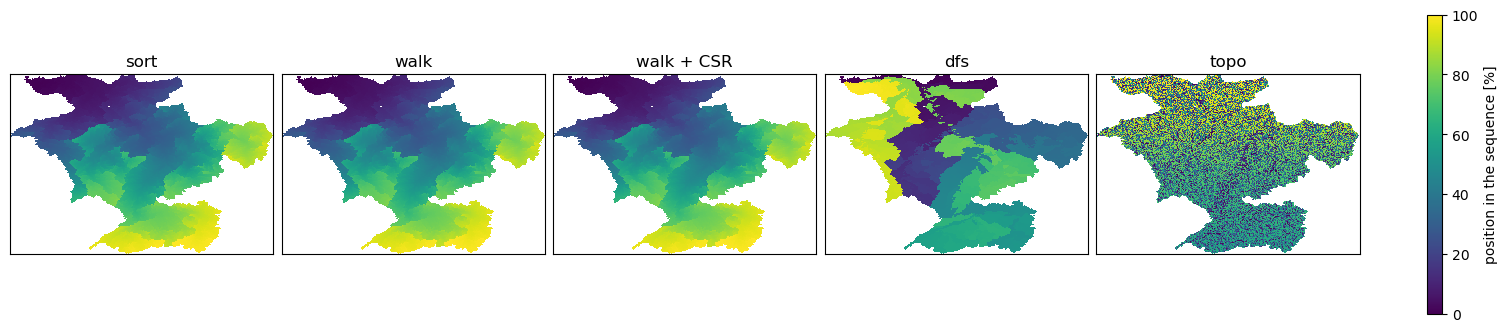

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.6), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (k, p) in zip(axes, pos.items()):
    img = np.ma.masked_less(p.reshape(flw.shape).astype(float) / n_valid * 100, 0)
    im = ax.imshow(img, cmap="viridis", interpolation="nearest", vmin=0, vmax=100)
    ax.set_title(k)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.85, label="position in the sequence [%]")
plt.show()

`sort` and the two walks lay down rings around the mouth; `dfs` gives each
subbasin one continuous stretch; `topo` releases every headwater at once, so
neighbours can sit far apart in the sequence.

Building them costs:

In [10]:
def timeit(fn, repeat=20):
    fn()                                                  # numba compiles here
    return min(_once(fn) for _ in range(repeat)) * 1e3

def _once(fn):
    t0 = time.perf_counter(); fn(); return time.perf_counter() - t0

memory = {                                                # values held at once
    "sort":       n * 4 + n * 8 + n_valid * itemsize,     # ranks, argsort, output
    "walk":       n * d * itemsize + n * itemsize,        # dense matrix, output
    "walk + CSR": (n + 1 + n_links) * itemsize + n * itemsize,
    "dfs":        (n + 1 + n_links) * itemsize + 2 * n_valid * itemsize,
    "topo":       n * itemsize + n_valid * itemsize,      # counts, output
}
t_build = {k: timeit(lambda fn=fn: fn(idxs_ds, idxs_pit, mv))
           for k, fn in ORDERINGS.items()}

print(f"{'':>11}  {'build ms':>9}  {'memory MB':>10}")
for k in ORDERINGS:
    print(f"{k:>11}  {t_build[k]:>9.1f}  {memory[k] / 1e6:>10.1f}")

              build ms   memory MB
       sort       20.0         9.6
       walk        6.9        21.8
 walk + CSR        4.1         6.8
        dfs        4.9         6.9
       topo        3.8         4.1


Memory is everything the ordering allocates, its output included, so `walk` here
is the 19.0 MB upstream matrix of section 1 plus the 2.7 MB it writes into.

`sort` is the slowest to build: `core.rank` already visits every cell once and
the `argsort` over `n` values comes on top. Between the two walks the dense
upstream matrix is the whole difference. `topo` is the lightest of the five, as
it never stores which cells are upstream, only how many.

## 3. What it costs the kernel that reads it

`streams.accuflux`, unchanged, given each of the five sequences. This is what
`FlwdirRaster.upstream_area` runs: it walks the sequence backwards and adds each
cell's area into the cell below it.

In [11]:
area = flw.area.ravel() / 1e6                             # cell area in km2

t_kernel, first = {}, None
for k, seq in seqs.items():
    t_kernel[k] = timeit(lambda seq=seq: streams.accuflux(idxs_ds, seq, area, -9999.0))
    out = streams.accuflux(idxs_ds, seq, area, -9999.0)
    if first is None:
        first = out
    else:
        assert np.allclose(out, first, rtol=1e-9, atol=0), k

print(f"{'':>11}  {'accuflux ms':>11}")
for k in ORDERINGS:
    print(f"{k:>11}  {t_kernel[k]:>11.1f}")
print()
print("The five agree on the upstream area to 1e-9 relative. A floating point sum")
print("is not associative, so the last bits follow the order the sum was taken in.")

             accuflux ms
       sort          1.0
       walk          1.1
 walk + CSR          1.1
        dfs          1.6
       topo          1.0

The five agree on the upstream area to 1e-9 relative. A floating point sum
is not associative, so the last bits follow the order the sum was taken in.


`dfs` is the slowest of the five, which is worth a second look: it is also the
one with by far the best memory locality. The next section takes that apart.

## 4. Why depth-first is the slowest here

`accuflux` reads `accu[idx0]` and writes `accu[idxs_ds[idx0]]`, both addressed by
cell index, so two properties of the sequence matter: how far apart consecutive
cells sit, and how long ago the cell being read was written.

In [12]:
@njit
def write_to_read(idxs_ds, s):
    """for each step, how many steps ago the cell it reads was last written"""
    last = np.full(idxs_ds.size, -1, np.int64)
    gap = np.full(s.size, -1, np.int64)
    for k in range(s.size):
        j = last[s[k]]
        if j >= 0:
            gap[k] = k - j
        last[idxs_ds[s[k]]] = k
    return gap[gap > 0]

print(f"{'':>11}  {'steps within one grid row':>25}  {'write to read, median':>22}")
for k, seq in seqs.items():
    s = seq[::-1].astype(np.int64)                        # the kernel's direction
    near = np.mean(np.abs(np.diff(s)) <= ncol + 1) * 100
    gap = write_to_read(idxs_ds.astype(np.int64), s)
    print(f"{k:>11}  {near:>24.0f}%  {np.median(gap):>22,.0f}")

             steps within one grid row   write to read, median


       sort                        12%                     230
       walk                        68%                     266
 walk + CSR                        68%                     266
        dfs                        91%                       1
       topo                        64%                  22,234


The first column is locality: how often the next read is close enough to the last
to already be in cache. `dfs` is far ahead, 91% against 12% for `sort`.

The second is how long a step has to wait. A step that reads a cell the previous
step has just written cannot start until that write has landed, so the two cannot
run at the same time. `dfs` walks down a single stream, so that is exactly what
happens, at a median gap of one step. The other orderings leave hundreds or
thousands of steps in between, far enough for the processor to fill the wait with
unrelated work.

The wait costs the same whatever the raster. What the locality is worth does not:
it depends on what a read costs, and that depends on how far the arrays reach past
the cache. A pointer chase over increasing working sets is the usual way to
measure that: each step lands where only the previous read can say, so nothing
can be fetched ahead and the time per step is the cost of one read.

In [13]:
@njit
def chase(nxt, steps):
    p = 0
    for _ in range(steps):
        p = nxt[p]                       # where to go next is only known once read
    return p

def cycle(size):
    perm = np.random.permutation(size)   # one random cycle through every slot
    nxt = np.empty(size, np.int64)
    nxt[perm[:-1]] = perm[1:]
    nxt[perm[-1]] = perm[0]
    return nxt

np.random.seed(0)
chase(cycle(1024), 1000)                 # numba compiles here
print(f"{'working set':>12}  {'one read':>9}")
for mb in [0.0625, 1, 8, 64, 512]:
    nxt, steps = cycle(int(mb * 2**20) // 8), 2_000_000
    chase(nxt, 1000)
    ns = min(_once(lambda: chase(nxt, steps)) for _ in range(5)) / steps * 1e9
    tag = f"{mb * 1024:.0f} KB" if mb < 1 else f"{mb:.0f} MB"
    print(f"{tag:>12}  {ns:>6.1f} ns")

 working set   one read
       64 KB     1.9 ns
        1 MB     5.8 ns


        8 MB    16.0 ns


       64 MB   100.3 ns


      512 MB   130.2 ns


The Rhine arrays come to 8 MB, near the middle of that range, where a read costs
roughly an order of magnitude less than on a raster that reaches well past the
cache. That is what a saved read is worth here, and it does not cover the wait.

## 5. A larger raster

A window of MERIT Hydro at 3 arcsec over eastern Asia, 90 to 123 E and 15 to
43 N: 33,600 x 39,600 = 1,330,560,000 cells, 609,079,064 of them with a flow
direction, 290,178 pits, `d` = 8. That is about two thousand times the Rhine
example. Same machine, same five orderings, same kernel. These numbers are not
from this notebook: they come from `examples/bench_large.py`, next to this
notebook, one process per ordering, best of three.

| ordering | build | memory | accuflux |
|---|--:|--:|--:|
| `sort` | 55 s | 17.1 GiB | 6.33 s |
| `walk` | 28.4 s | 44.6 GiB | 6.23 s |
| `walk + CSR` | 10.9 s | 12.2 GiB | 6.23 s |
| `dfs` | 10.2 s | 11.8 GiB | **3.44 s** |
| `topo` | **7.7 s** | **7.2 GiB** | 4.22 s |

Memory is what the ordering allocates, from the same arithmetic as section 2;
peak resident memory matches it except where the operating system evicts pages
mid-run, which it did for `walk`, so the arithmetic is the honest column. `walk`
and `walk + CSR` return the same sequence here too, checked by hashing both, so
the `accuflux` column is one measurement entered twice.

Two things have changed from the Rhine.

**The dense upstream matrix is now the largest object in the program.** It is
`1,330,560,000 x 8 x 4` bytes, 39.7 GiB, holding 608,788,886 upstream cells that
fit in 7.2 GiB. This machine has 64 GiB and built it in 28.4 s against 11.4 s for
the CSR one. A machine with 32 GiB has less memory in total than that one array,
so it would have to be paged to disk; what that costs I have not measured.

**Depth-first has gone from slowest to fastest**, 1.8 times faster through
`accuflux` than either the breadth-first walk or the sort. The wait it pays has not
changed and neither has the code. What changed is the price of a read: the Rhine
arrays came to 8 MB, inside the 12 MB level 2 cache, where the table in section 4
puts a read well under 20 ns; these arrays are several gigabytes, and there a read
costs about 130 ns. The misses depth-first avoids are worth roughly an order of
magnitude more than they were, and that covers the wait.

## 6. What this comes to

`walk + CSR` returns the same sequence as `walk` for under a third of the memory
and three fifths of the build time on the Rhine, and 7.2 GiB against 39.7 GiB of
upstream cells on the larger raster. That is the pull request, and it has nothing
to weigh against.

`dfs` and `topo` are a choice. Both are cheaper to build than anything in the
library today, and `topo` is the lightest of the five by some way. For the
accumulation itself `dfs` is the one that pays off once the arrays no longer fit
in cache, which is where the large rasters are, and it is the worst below that.
If they are worth having they fit as two more `order_cells` methods and change
nothing that exists.

**Reproducing this.** Sections 1 to 4 need only pyflwdir and this repository's
`examples/rhine_d8.tif`. Section 5 reads a flat `int32` array of next-downstream
indices, exported from any raster with `flw.idxs_ds.astype("int32").tofile(...)`,
through `examples/bench_large.py` next to this notebook; on the window above it
takes about a quarter of an hour, and its `walk` row allocates 44.6 GiB.

### References

Braun, J. and Willett, S. D. (2013). A very efficient O(n), implicit and parallel
method to solve the stream power equation governing fluvial incision and
landscape evolution. *Geomorphology*, 180-181, 170-179.

Kahn, A. B. (1962). Topological sorting of large networks. *Communications of the
ACM*, 5(11), 558-562.